In [1]:
import pandas as pd

# loading the cleaned CSV data and printing some basic information about the dataset
df = pd.read_csv('./data/00-raw/steam_games_2026_cleaned.csv')
print(df.shape)
print(df.dtypes)
print(df[['All_Tags', 'Review_Score_Pct', 'Total_Reviews', 'Total_Reviews']].head(3))
print(df['Review_Score_Pct'].describe())

# Lists all unique tags in the dataset
all_tags = set()
for tags_str in df['All_Tags'].dropna():
    for tag in tags_str.split(';'):
        all_tags.add(tag.strip())

# tags_sorted = sorted(all_tags)
# print(f"Total unique tags: {len(tags_sorted)}\n")
# for tag in tags_sorted:
#     print(tag)

(5417, 6)
AppID                int64
Release_Date         int64
Name                object
All_Tags            object
Review_Score_Pct     int64
Total_Reviews        int64
dtype: object
                                            All_Tags  Review_Score_Pct  \
0  FPS;Shooter;Multiplayer;Competitive;Action;Tea...                82   
1  Free to Play;Hero Shooter;FPS;Multiplayer;Team...                55   
2  Free to Play;Battle Royale;Multiplayer;FPS;Sho...                70   

   Total_Reviews  Total_Reviews  
0        5080174        5080174  
1            267            267  
2           1576           1576  
count    5417.000000
mean       82.747092
std        13.033373
min         9.000000
25%        76.000000
50%        86.000000
75%        92.000000
max       100.000000
Name: Review_Score_Pct, dtype: float64


In [2]:
df['tag'] = df['All_Tags'].str.split(';')
exploded = df.explode('tag')
exploded['tag'] = exploded['tag'].str.strip()

tag_stats = (
    exploded.groupby('tag').agg(
        avg_review_score = ('Review_Score_Pct', 'mean'),
        game_count = ('AppID', 'count'),
        median_review_score = ('Review_Score_Pct', 'median')
    )
    .reset_index()
)

tags_filtered = tag_stats[tag_stats['game_count'] >= 500].copy()
tags_filtered = tags_filtered.sort_values(by='avg_review_score', ascending=False)

print(f"Unique Tags: {len(tag_stats)}")
print(f"Tags with >= 500 Games: {len(tags_filtered)}")
print("\nTop 20 Tags by Average Review Score:")
print(tags_filtered.head(20).to_string(index=False))
print("\nBottom 20 Tags by Average Review Score:")
print(tags_filtered.tail(20).to_string(index=False))

Unique Tags: 437
Tags with >= 500 Games: 21

Top 20 Tags by Average Review Score:
         tag  avg_review_score  game_count  median_review_score
          2D         87.636800         625                 90.0
      Puzzle         87.322642         530                 90.0
  Story Rich         86.408342         911                 89.0
       Indie         86.065744         867                 89.0
 Atmospheric         84.774092         633                 88.0
      Casual         84.516332         796                 88.0
      Horror         84.171617         606                 88.0
Singleplayer         83.313835        1966                 86.0
   Adventure         83.258565        1547                 86.0
 Exploration         83.175824         819                 86.0
          3D         82.334992         603                 86.0
  Simulation         81.914189        1177                 85.0
    Strategy         81.722772        1010                 84.0
First-Person         8

In [3]:
print("\nTags with >= 500 Games by Average Review Score:")
print(tags_filtered.to_string(index=False))


Tags with >= 500 Games by Average Review Score:
         tag  avg_review_score  game_count  median_review_score
          2D         87.636800         625                 90.0
      Puzzle         87.322642         530                 90.0
  Story Rich         86.408342         911                 89.0
       Indie         86.065744         867                 89.0
 Atmospheric         84.774092         633                 88.0
      Casual         84.516332         796                 88.0
      Horror         84.171617         606                 88.0
Singleplayer         83.313835        1966                 86.0
   Adventure         83.258565        1547                 86.0
 Exploration         83.175824         819                 86.0
          3D         82.334992         603                 86.0
  Simulation         81.914189        1177                 85.0
    Strategy         81.722772        1010                 84.0
First-Person         81.464576         861             

In [4]:
import pandas as pd

df = pd.read_parquet('./data/00-raw/data_compat.parquet')

# Reconstruct the original dict structure
data = {app_id: group.drop(columns='app_id').set_index('review_id') 
        for app_id, group in df.groupby('app_id')}

print(df.columns.tolist())
print(df.head())
print(df.dtypes)

['app_id', 'review_id', 'timestamp_created', 'voted_up']
   app_id  review_id  timestamp_created  voted_up
0     730  226529321               2026      True
1     730  226529070               2026      True
2     730  226528922               2026      True
3     730  226528679               2026      True
4     730  226528349               2026      True
app_id               int32
review_id            int64
timestamp_created    int32
voted_up              bool
dtype: object


In [5]:
pip install pyarrow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
# TIME GRAPH

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
 
# LOAD PARQUET DATA INTO DICT
df_parquet = pd.read_parquet('./data/00-raw/data_compat.parquet')
data = {app_id: group.drop(columns='app_id').set_index('review_id')
        for app_id, group in df_parquet.groupby('app_id')}

# CSV FILE DIRECTORY HERE
df_csv = pd.read_csv('./data/00-raw/steam_games_2026_cleaned.csv')
df_overlap = df_csv[df_csv['AppID'].isin(data.keys())]

# Creating the app id tags mapping
appid_tags = {}
for _, row in df_overlap.iterrows():
    tags = row['All_Tags'].split(';') if pd.notna(row['All_Tags']) else []
    appid_tags[row['AppID']] = tags[:10] # NUMBER OF FRONT TAGS FROM A GAME COUNTING TOWARD THE DATA

In [7]:
# Checks Tags with at least 20 games for clutter control's sake 

from collections import Counter
 
tag_game_counts = Counter()
for tags in appid_tags.values():
    for tag in tags:
        tag_game_counts[tag] += 1
 
eligible_tags = sorted(
    [(tag, count) for tag, count in tag_game_counts.items() if count >= 20],
    key = lambda x: -x[1],
)

# Prints eligible tags and their game counts (Don't need to right now)
# print(f"Tags with ≥20 games ({len(eligible_tags)} total):")
# for tag, count in eligible_tags:
#     print(f"  {count:>4}  {tag}")

In [8]:
# Grouping tags together based on relevance and similarity to create broader categories for analysis(and for easier visualization)

TAG_GROUPS = {
    "FPS / Shooter":         ["FPS", "Shooter", "First-Person", "Third-Person Shooter", "War", "Realistic",
                              "Military", "Boomer Shooter", "Arena Shooter", "Extraction Shooter", "Looter Shooter"],
    "Multiplayer / Online":  ["Multiplayer", "Online Co-Op", "Co-op", "PvP", "PvE", "Massively Multiplayer",
                              "Team-Based", "Local Co-Op", "Local Multiplayer", "Co-op Campaign", "MMORPG", "eSports"],
    "Open World / Survival": ["Open World", "Survival", "Open World Survival Craft", "Exploration", "Sandbox",
                              "Base Building", "Building", "Crafting", "Mining", "Fishing", "Automation", "Nature"],
    "Action / Combat":       ["Action", "Hack and Slash", "Action RPG", "Action-Adventure", "Third Person",
                              "Character Customization", "Combat", "Beat 'em up", "Fighting", "Martial Arts",
                              "Swordplay", "Spectacle fighter", "Parkour", "Stealth", "Assassin", "Loot"],
    "RPG / Story":           ["RPG", "Adventure", "Story Rich", "Singleplayer", "Fantasy", "JRPG", "CRPG",
                              "Party-Based RPG", "Tactical RPG", "Strategy RPG", "Dark Fantasy", "Mythology",
                              "Choices Matter", "Multiple Endings", "Romance", "Narrative", "Dungeon Crawler"],
    "Strategy / Simulation": ["Strategy", "Simulation", "Early Access", "Historical", "Management", "Tactical",
                              "Casual", "RTS", "Turn-Based Strategy", "Turn-Based", "Turn-Based Combat",
                              "Turn-Based Tactics", "Grand Strategy", "4X", "Wargame", "Real Time Tactics",
                              "City Builder", "Colony Sim", "Economy", "Resource Management", "God Game",
                              "Auto Battler", "Tower Defense", "Diplomacy"],
    "Puzzle / Platformer":   ["Puzzle", "Platformer", "2D Platformer", "3D Platformer", "Puzzle Platformer",
                              "Metroidvania", "Precision Platformer", "Logic", "Hidden Object", "Escape Room",
                              "Point & Click", "Walking simulator"],
    "Horror / Dark":         ["Horror", "Psychological Horror", "Survival Horror", "Sci-fi", "Zombies", "Gore",
                              "Post-apocalyptic", "Dark", "Dark Fantasy", "Lovecraftian", "Supernatural",
                              "Thriller", "Mystery", "Detective", "Crime", "Noir"],
    "Roguelike":             ["Roguelike", "Roguelite", "Action Roguelike", "Roguelike Deckbuilder",
                              "Bullet Hell", "Perma Death"],
    "Visual Novel / Narrative": ["Visual Novel", "Interactive Fiction", "Dating Sim", "Choose Your Own Adventure",
                                 "Text-Based", "FMV", "Otome"],
    "Racing / Sports":       ["Racing", "Driving", "Sports", "Automobile Sim", "Combat Racing",
                              "Vehicular Combat", "Flight", "Space Sim", "Naval", "Naval Combat", "Sailing"],
    "Card / Board":          ["Card Game", "Deckbuilding", "Card Battler", "Board Game", "Tabletop",
                              "Trading Card Game", "Warhammer 40K", "Dungeons & Dragons"],
    "Space / Sci-fi":        ["Space", "Sci-fi", "Futuristic", "Aliens", "Mechs", "Cyberpunk",
                              "Transhumanism", "Robots"],
}

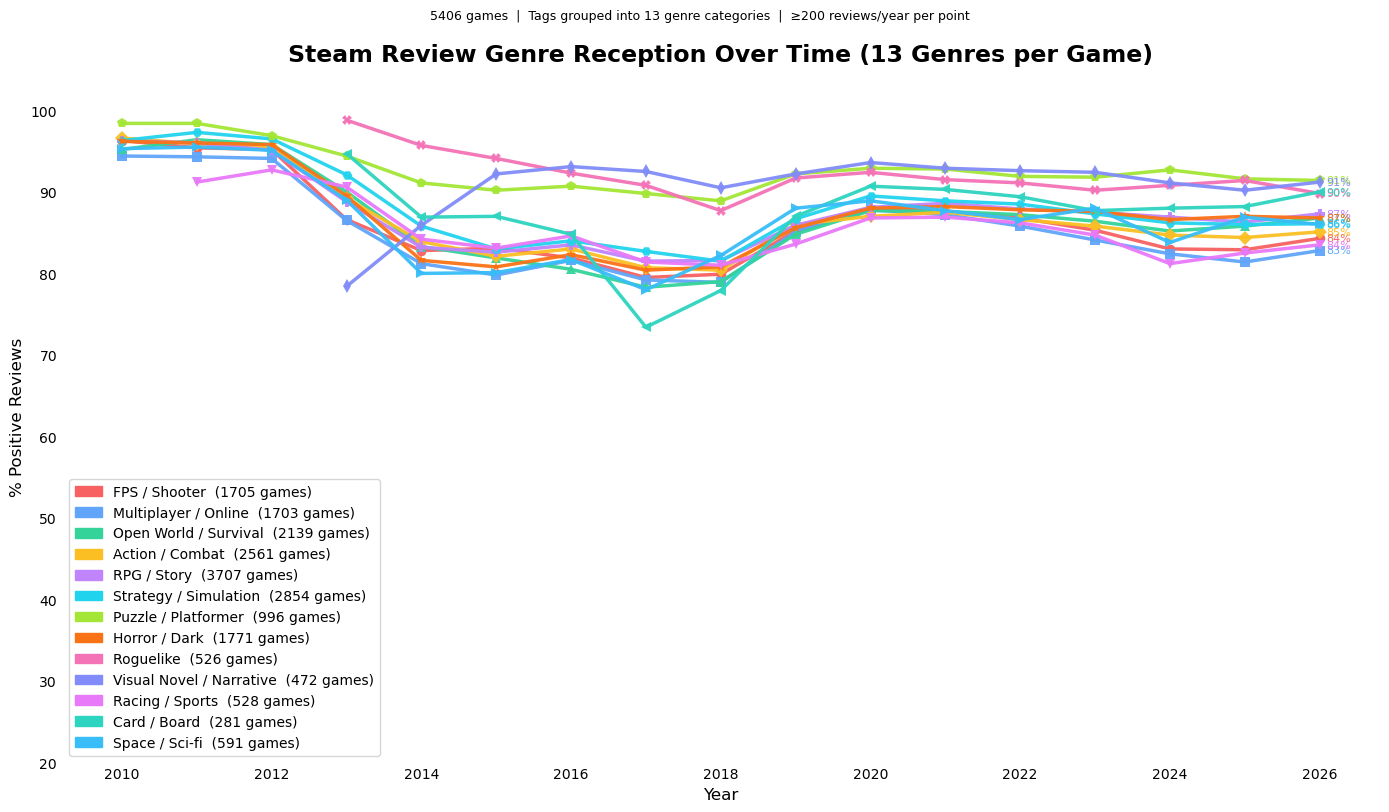

In [10]:
# 1 Genre per game is a bit restrictive, so let's try allowing games to be in any number of groups that we allow

MAX_GROUPS = 13 # MAX GROUPS PER GAME (FEEL FREE TO CHANGE)
# Assign each game to its groups (based on highest tag count)
def assign_groups(game_tags, tag_groups, csv_tag_counts, max_groups=MAX_GROUPS):
    """Return up to max_groups best-fit groups ranked by (# matched tags,
total CSV game-count of matched tags). Groups with zero matches excluded."""
    scores = []
    for group, members in tag_groups.items():
        matched = set(game_tags) & set(members)
        if matched:
            score = (len(matched), sum(csv_tag_counts.get(t, 0) for t in matched))
            scores.append((score, group))
    scores.sort(reverse = True)
    return [group for _, group in scores[:max_groups]]


# Counts through games and the tags in the CSV for tie-breaking 
csv_tag_counts = Counter()
for tags_str in df_csv['All_Tags'].dropna():
    for tag in tags_str.split(';'):
        csv_tag_counts[tag.strip()] += 1

appid_groups = {}
for app_id, tags in appid_tags.items():
    groups = assign_groups(tags, TAG_GROUPS, csv_tag_counts, max_groups = MAX_GROUPS)
    if groups:
        appid_groups[app_id] = groups


# Aggregate of the group to the year, the total reviews and the positive/negative reviews
group_year_stats = defaultdict(lambda: defaultdict(lambda: [0, 0]))
group_game_sets  = defaultdict(set)
 
for app_id, reviews_df in data.items():
    # Skips games with no tag data (shouldn't be necessary if the data is clean, but just here for redudancy)
    if app_id not in appid_tags:
        continue
    groups = appid_groups.get(app_id)
    if not groups:
        continue

    # Gets the tags for the game as a set, and makes sure 'voted up' is boolean
    game_tags = set(appid_tags[app_id])
    reviews_df = reviews_df.copy()
    reviews_df['voted_up'] = reviews_df['voted_up'].astype(bool)

    # Groups reviews by year and then compares positive reviews with total reviews (for percent positive)
    year_stats = (
        reviews_df
        .groupby('timestamp_created')['voted_up']
        .agg(['sum', 'count'])
        .reset_index()
    )

    # Finds the best tag groups for this game based on the number of matching tags, and then by the total game count of those tags in the CSV for tie-breaking
    for group in groups:
        group_game_sets[group].add(app_id)
        for _, row in year_stats.iterrows():
            year = int(row['timestamp_created'])
            group_year_stats[group][year][0] += int(row['count'])
            group_year_stats[group][year][1] += int(row['sum'])
 
# Building the dataframe for sns 
MIN_REVIEWS = 200   # minimum reviews per year/group point to include
MIN_POINTS  = 4     # minimum yearly data points for a group to be plotted

# Converts the count into a list, Score: approval percent; and only counts years with at least 200 reviews
records = []
for group in TAG_GROUPS:
    for year, (total, pos) in group_year_stats[group].items():
        if total >= MIN_REVIEWS:
            records.append({
                "Group": group,
                "Year":  year,
                "Score": round(100 * pos / total, 1),
                "Games": len(group_game_sets[group]),
            })
 
df_plot = pd.DataFrame(records)
df_plot = df_plot[df_plot.groupby("Group")["Year"].transform("count") >= MIN_POINTS]
 
# Visual stuff
GROUP_PALETTE = {
    "FPS / Shooter":            "#f76161",
    "Multiplayer / Online":     "#60a5fa",
    "Open World / Survival":    "#34d399",
    "Action / Combat":          "#fbbf24",
    "RPG / Story":              "#c084fc",
    "Strategy / Simulation":    "#22d3ee",
    "Puzzle / Platformer":      "#a3e635",
    "Horror / Dark":            "#f97316",
    "Roguelike":                "#f472b6",
    "Visual Novel / Narrative": "#818cf8",
    "Racing / Sports":          "#e879f9",
    "Card / Board":             "#2dd4bf",
    "Space / Sci-fi":           "#38bdf8",
}
# Shape markers for each group
MARKERS = {
    "FPS / Shooter":            "o",
    "Multiplayer / Online":     "s",
    "Open World / Survival":    "^",
    "Action / Combat":          "D",
    "RPG / Story":              "P",
    "Strategy / Simulation":    "H",
    "Puzzle / Platformer":      "p",
    "Horror / Dark":            "*",
    "Roguelike":                "X",
    "Visual Novel / Narrative": "d",
    "Racing / Sports":          "v",
    "Card / Board":             "<",
    "Space / Sci-fi":           ">",
}
 
# THE PLOT ITSELF (with tons of custom formatting because im a vis major lol)
fig, ax = plt.subplots(figsize = (17, 9))

 
groups_present = df_plot["Group"].unique()
 
for group in groups_present:
    gdf    = df_plot[df_plot["Group"] == group].sort_values("Year")
    color  = GROUP_PALETTE[group]
    marker = MARKERS[group]
    n_games = int(gdf["Games"].iloc[0])
 
    sns.lineplot(
        data = gdf, x = "Year", y = "Score",
        ax = ax, color=color, linewidth = 2.5,
        marker = marker, markersize = 7,
        markeredgewidth = 0, alpha = 0.95,
        label = f"{group}  ({n_games} games)",
        legend = False,
    )

    # Creates the percentage label at the end of each line
    last = gdf.iloc[-1]
    ax.annotate(
        f'{last["Score"]:.0f}%',
        xy = (last["Year"], last["Score"]),
        xytext = (5, 0), textcoords = 'offset points',
        color = color, fontsize = 8, va = 'center',
    )
 
 
 
# Organizes the axes and the year grids so they line up properly with the data points
ax.set_yticks(range(20, 101, 10))
ax.set_ylim(20, 105)

ax.tick_params(length = 0)
for sp in ax.spines.values():
    sp.set_visible(False)
 
# Creates Labels & title 
ax.set_title(
    f'Steam Review Genre Reception Over Time ({MAX_GROUPS} Genres per Game)',
    fontsize = 17, fontweight = 'bold'
)
ax.set_xlabel('Year', fontsize = 12)
ax.set_ylabel('% Positive Reviews', fontsize = 12)

# General info above the title
sub = (
    f"{len(data)} games  |  Tags grouped into {len(groups_present)} genre categories"
    f"  |  ≥{MIN_REVIEWS} reviews/year per point"
)
fig.text(0.5, 0.936, sub, ha='center', fontsize = 9)
 
# Legend
handles = [
    mpatches.Patch(
        color = GROUP_PALETTE[g],
        label = f"{g}  ({int(df_plot[df_plot['Group'] == g]['Games'].iloc[0])} games)",
    )
    for g in groups_present
]

# Legend with group names, game counts, color, and puts them in the corner and not all the way in the middle of nowhere
ax.legend(
    handles = handles,
    loc = 'lower left',
)

